In [1]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter, defaultdict


---
---

Text(0.5, 1.0, 'Weekly samples & defect ratio')

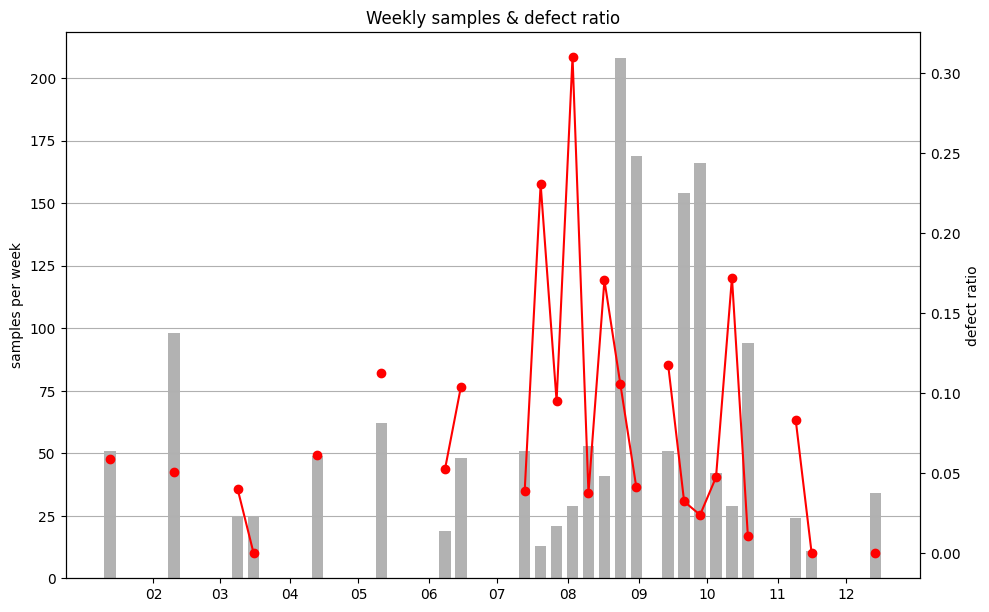

In [3]:
secom = pd.read_csv(data_path, sep='\t')
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

time_dt = pd.to_datetime(secom['Time'])
df = pd.DataFrame({'Time':time_dt, 'y':y}).sort_values('Time').set_index('Time')

w = df['y'].resample('W') # W means the end of the date
cnt, rate = w.size(), w.mean() # rate means 1/0 (fail/pass) less is better

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(cnt.index, cnt.values, width=5, alpha=0.3, color='k')
ax1.set_ylabel('samples per week')
ax1.grid(True, axis='y')

ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, marker='o', color='r')
ax2.set_ylabel('defect ratio')
months = pd.date_range(rate.index.min().normalize(),
                       rate.index.max().normalize(), freq='MS') 
ax2.set_xticks(months)
ax2.set_xticklabels([d.strftime('%m') for d in months], rotation=0, ha='center')

plt.tight_layout()
plt.title('Weekly samples & defect ratio')


---
---

### 所有機器學習模型的10折結果, 作缺值, 相關性特徵選擇, 中位數補值
| Model              |   ACC  |   FAR  | Sensitivity | Specificity |   GM   |
| :----------------- | :----: | :----: | :---------: | :---------: | :----: |
| **RandomForest**   | 0.9066 | 0.0410 |    0.1708   |    0.9590   | 0.3497 |
| **XGBoost**        | 0.9282 | 0.0103 |    0.0583   |    0.9897   | 0.1296 |
| **SVC**            | 0.9266 | 0.0111 |    0.0486   |    0.9889   | 0.1187 |
| **DecisionTree**   | 0.7925 | 0.1718 |    0.2917   |    0.8282   | 0.4733 |
| **Lasso-Logistic** | 0.8484 | 0.1145 |    0.3250   |    0.8855   | 0.4652 |
| **LinearReg**      | 0.8061 | 0.1607 |    0.3389   |    0.8393   | 0.5092 |

[RandomForest] MEAN acc=0.9066 FAR=0.0410 sens=0.1708 spec=0.9590 GM=0.3497
[XGBoost] MEAN acc=0.9282 FAR=0.0103 sens=0.0583 spec=0.9897 GM=0.1296
[SVC] MEAN acc=0.9266 FAR=0.0111 sens=0.0486 spec=0.9889 GM=0.1187
[DecisionTree] MEAN acc=0.7925 FAR=0.1718 sens=0.2917 spec=0.8282 GM=0.4733
[Lasso-Logistic] MEAN acc=0.8484 FAR=0.1145 sens=0.3250 spec=0.8855 GM=0.4652
[LinearReg] MEAN acc=0.8061 FAR=0.1607 sens=0.3389 spec=0.8393 GM=0.5092


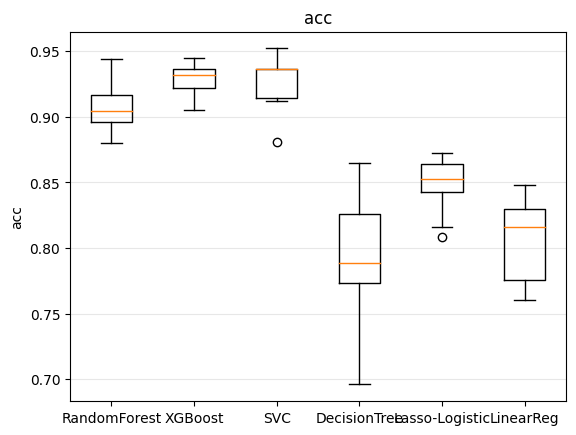

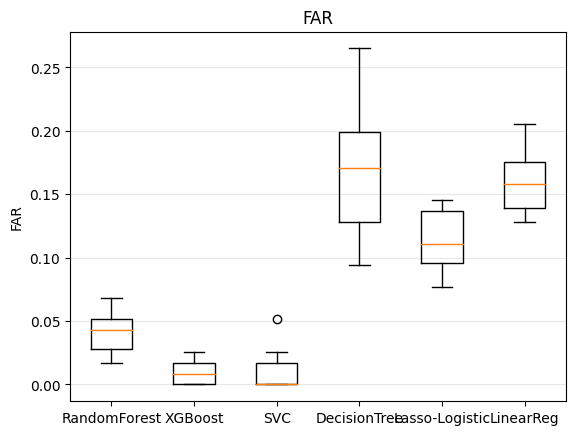

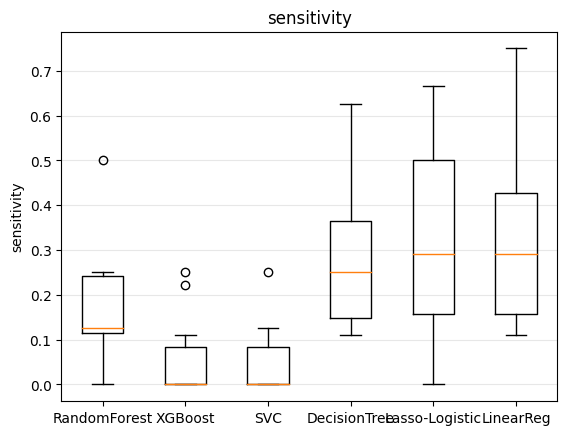

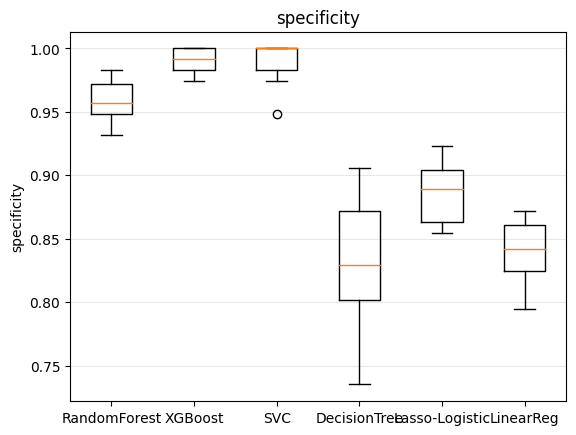

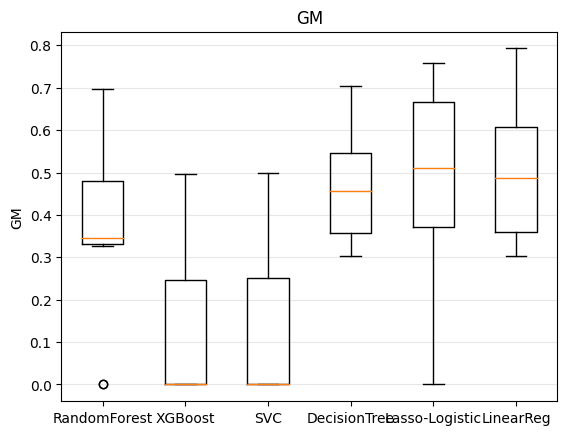

In [16]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}")
    return avg, df

imp = SimpleImputer(strategy='median')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

svc_pipe = Pipeline(steps=[('impute', imp),
                           ('scaler', StandardScaler()),
                           ('smote', smote),
                           ('svc', SVC(kernel='rbf', C=1.0, gamma='auto', class_weight='balanced', random_state=42))])

xgb_pipe = Pipeline(steps=[('impute', imp),
                           ('smote', smote),
                           ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, tree_method='hist'))])

lasso_logit_pipe = Pipeline(steps=[('impute', imp),
                                   ('scaler', StandardScaler()),
                                   ('smote', smote),
                                   ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, random_state=42))])

rfc_pipe = Pipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, class_weight='balanced', random_state=42, n_jobs=-1))])

dt_pipe = Pipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'))])

linr_pipe = Pipeline(steps=[('impute', imp),
                            ('scaler',StandardScaler()),
                            ('smote', smote),
                            ('clf', LinearRegression())])

models = [('RandomForest', rfc_pipe), ("XGBoost", xgb_pipe), ('SVC', svc_pipe), ("DecisionTree", dt_pipe), ("Lasso-Logistic", lasso_logit_pipe), ("LinearReg", linr_pipe)]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)

cv_df = pd.concat(fold_dfs, ignore_index=True)  # 欄位：model, fold, acc, FAR, sensitivity, specificity, GM

# 盒鬚圖
for metric in METRICS:
    plt.figure()
    data = [cv_df.loc[cv_df['model']==m, metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric}')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()



---
### 所有機器學習模型的10折結果, 不作特徵選擇, KNN補值
| Model              |   ACC  |   FAR  | Sensitivity | Specificity |   GM   |
| :----------------- | :----: | :----: | :---------: | :---------: | :----: |
| **RandomForest**   | 0.9091 | 0.0419 |    0.2194   |    0.9581   | 0.3998 |
| **XGBoost**        | 0.9258 | 0.0111 |    0.0347   |    0.9889   | 0.0820 |
| **SVC**            | 0.9266 | 0.0111 |    0.0486   |    0.9889   | 0.1187 |
| **DecisionTree**   | 0.8093 | 0.1564 |    0.3264   |    0.8436   | 0.5108 |
| **Lasso-Logistic** | 0.8396 | 0.1214 |    0.2903   |    0.8786   | 0.4662 |
| **LinearReg**      | 0.8069 | 0.1632 |    0.3861   |    0.8368   | 0.5495 |



[RandomForest] MEAN acc=0.9091 FAR=0.0419 sens=0.2194 spec=0.9581 GM=0.3998
[XGBoost] MEAN acc=0.9258 FAR=0.0111 sens=0.0347 spec=0.9889 GM=0.0820
[SVC] MEAN acc=0.9266 FAR=0.0111 sens=0.0486 spec=0.9889 GM=0.1187
[DecisionTree] MEAN acc=0.8093 FAR=0.1564 sens=0.3264 spec=0.8436 GM=0.5108
[Lasso-Logistic] MEAN acc=0.8396 FAR=0.1214 sens=0.2903 spec=0.8786 GM=0.4662
[LinearReg] MEAN acc=0.8069 FAR=0.1632 sens=0.3861 spec=0.8368 GM=0.5495


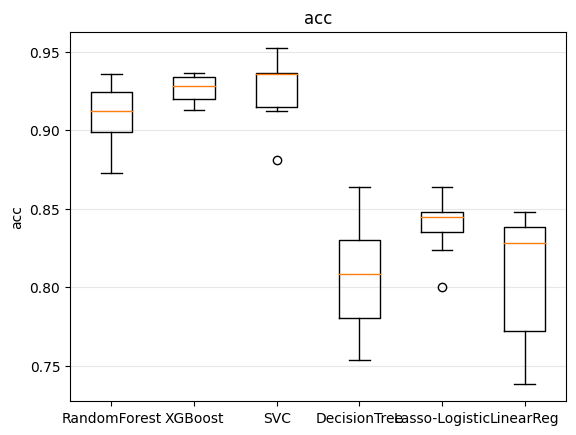

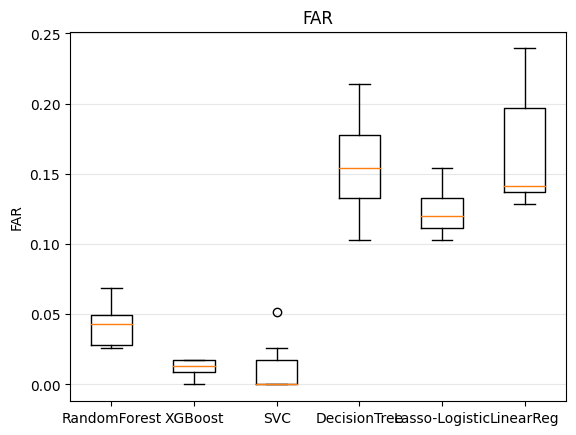

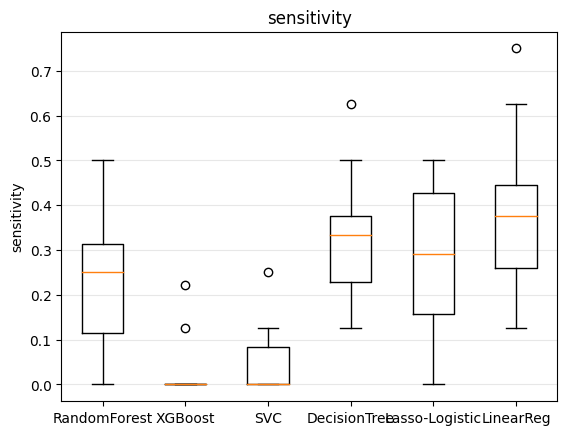

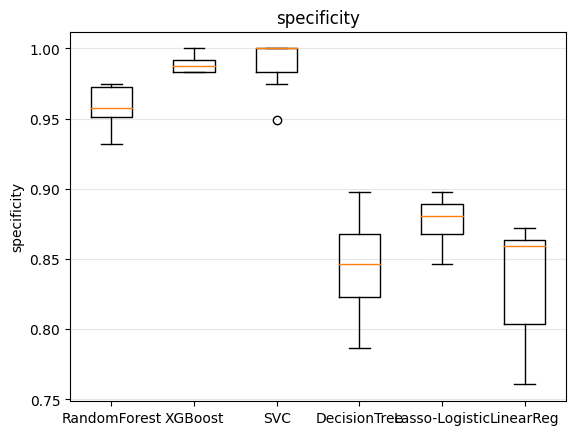

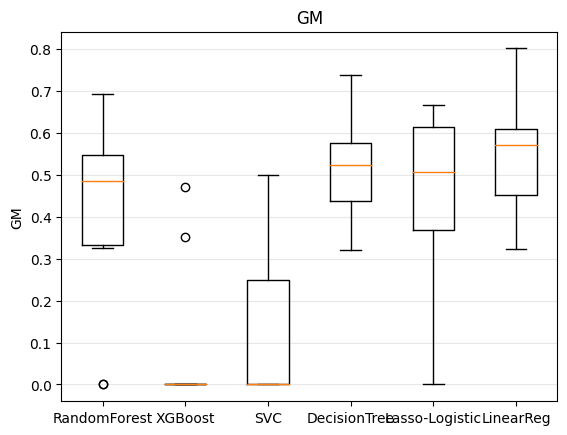

In [ ]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}")
    return avg, df

knn = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

svc_pipe = Pipeline(steps=[('impute', imp),
                           ('scaler', StandardScaler()),
                           ('smote', smote),
                           ('svc', SVC(kernel='rbf', C=1.0, gamma='auto', class_weight='balanced', random_state=42))])

xgb_pipe = Pipeline(steps=[('impute', knn),
                           ('smote', smote),
                           ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss',tree_method='hist'))])

lasso_logit_pipe = Pipeline(steps=[('impute', knn),
                                   ('scaler', StandardScaler()),
                                   ('smote', smote),
                                   ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, random_state=42))])

rfc_pipe = Pipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, class_weight='balanced', random_state=42, n_jobs=-1))])

dt_pipe = Pipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'))])

linr_pipe = Pipeline(steps=[('impute', knn),
                            ('scaler',StandardScaler()),
                            ('smote', smote),
                            ('clf', LinearRegression())])

models = [('RandomForest', rfc_pipe), ("XGBoost", xgb_pipe), ('SVC', svc_pipe), ("DecisionTree", dt_pipe), ("Lasso-Logistic", lasso_logit_pipe), ("LinearReg", linr_pipe)]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)

cv_df = pd.concat(fold_dfs, ignore_index=True)  # 欄位：model, fold, acc, FAR, sensitivity, specificity, GM

# 盒鬚圖
for metric in METRICS:
    plt.figure()
    data = [cv_df.loc[cv_df['model']==m, metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric}')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()


---
---

### 0.2測試 0.8訓練再拆成10折, 每折先做隨機森林特徵篩選, KNN補值, SMOTE過度抽樣, 決策樹訓練後, 再用驗證取最佳的k, 取得被取到10次的features來做最後的測試

#### 有SMOTE

In [4]:
secom = pd.read_csv(data_path, sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

knn_imp = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)

rf_ = dict(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
dt_ = dict(random_state=42, class_weight='balanced', max_depth=6)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def candidate_k_list(p, m=12):
    m = min(m, p)
    ks = np.unique(np.linspace(min(10, p), p, num=m, dtype=int))
    ks = ks[ks > 0]
    return ks

best_k_per_fold = []
features_per_fold = []
feature_pick_counter = Counter()

for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    
    rf = RandomForestClassifier(**rf_)
    rf.fit(X_tr, y_tr)

    importances = pd.Series(rf.feature_importances_, index=X_tr.columns)
    order = importances.sort_values(ascending=False).index.tolist()

    # 針對不同前 k 個特徵：KNN 補值（只用訓練 fit）、決策樹在 valid 算 acc，取最佳 k
    ks = candidate_k_list(p=len(order), m=12)
    best_acc, best_k, best_feats = -1.0, None, None

    for k in ks:
        sel = order[:k]

        X_tr_sel_imp = pd.DataFrame(knn_imp.fit_transform(X_tr[sel]), columns=sel, index=X_tr.index)
        X_va_sel_imp = pd.DataFrame(knn_imp.transform(X_va[sel]), columns=sel, index=X_va.index)

        X_tr_res, y_tr_res = smote.fit_resample(X_tr_sel_imp, y_tr)

        clf = DecisionTreeClassifier(**dt_)
        clf.fit(X_tr_res, y_tr_res)
        va_pred = clf.predict(X_va_sel_imp)
        acc = accuracy_score(y_va, va_pred)

        if acc > best_acc:
            best_acc, best_k, best_feats = acc, k, sel

    best_k_per_fold.append((fold_id, best_k, best_acc))
    features_per_fold.append((fold_id, best_feats))
    feature_pick_counter.update(best_feats)

# ---- 輸出 ----
print("每折最佳 k 與驗證集 accuracy：")
for fid, bk, ba in best_k_per_fold:
    print(f"[Fold {fid:02d}] best_k={bk:<4d}  valid_acc={ba:.4f}")

feat_counts_df = pd.DataFrame(feature_pick_counter.most_common(), columns=['feature', 'selected_count'])

top = feat_counts_df[feat_counts_df['selected_count']==10]['feature'].tolist()

Xtr_imp = pd.DataFrame(knn_imp.fit_transform(X_train[top]), columns=top, index=X_train.index)
Xte_imp = pd.DataFrame(knn_imp.transform(X_test[top]), columns=top, index=X_test.index)

clf = DecisionTreeClassifier(**dt_)
clf.fit(Xtr_imp, y_train)
yhat = clf.predict(Xte_imp)

res = compute_metrics(y_test, yhat)
print(f"[TEST] acc={res['acc']:.4f} FAR={res['FAR']:.4f} sens={res['sensitivity']:.4f} spec={res['specificity']:.4f} GM={res['GM']:.4f}")
print(res['cm'])

每折最佳 k 與驗證集 accuracy：
[Fold 01] best_k=168   valid_acc=0.8333
[Fold 02] best_k=327   valid_acc=0.8333
[Fold 03] best_k=447   valid_acc=0.8254
[Fold 04] best_k=407   valid_acc=0.9040
[Fold 05] best_k=248   valid_acc=0.9120
[Fold 06] best_k=10    valid_acc=0.8320
[Fold 07] best_k=129   valid_acc=0.8720
[Fold 08] best_k=367   valid_acc=0.9280
[Fold 09] best_k=447   valid_acc=0.8480
[Fold 10] best_k=407   valid_acc=0.8240
[TEST] acc=0.8248 FAR=0.1399 sens=0.3333 spec=0.8601 GM=0.5354
[[252  41]
 [ 14   7]]


In [5]:
feat_counts_df[feat_counts_df['selected_count'] ==10]


,feature,selected_count
0,x66,10
1,x65,10
2,x104,10
3,x60,10
4,x206,10
5,x478,10
6,x342,10
7,x563,10
8,x511,10
9,x133,10


[CV-ON-ORIG Fold 01] acc=0.8344 FAR=0.1565 sens=0.7000 spec=0.8435 GM=0.7684
[CV-ON-ORIG Fold 02] acc=0.7643 FAR=0.2041 sens=0.3000 spec=0.7959 GM=0.4886
[CV-ON-ORIG Fold 03] acc=0.7389 FAR=0.2449 sens=0.5000 spec=0.7551 GM=0.6145
[CV-ON-ORIG Fold 04] acc=0.8025 FAR=0.1644 sens=0.3636 spec=0.8356 GM=0.5512
[CV-ON-ORIG Fold 05] acc=0.7898 FAR=0.1849 sens=0.4545 spec=0.8151 GM=0.6087
[CV-ON-ORIG Fold 06] acc=0.8344 FAR=0.1438 sens=0.5455 spec=0.8562 GM=0.6834
[CV-ON-ORIG Fold 07] acc=0.5350 FAR=0.4658 sens=0.5455 spec=0.5342 GM=0.5398
[CV-ON-ORIG Fold 08] acc=0.8077 FAR=0.1644 sens=0.4000 spec=0.8356 GM=0.5781
[CV-ON-ORIG Fold 09] acc=0.7885 FAR=0.1781 sens=0.3000 spec=0.8219 GM=0.4966
[CV-ON-ORIG Fold 10] acc=0.7244 FAR=0.2603 sens=0.5000 spec=0.7397 GM=0.6082
[CV-ON-ORIG MEAN] acc=0.7620 FAR=0.2167 sens=0.4609 spec=0.7833 GM=0.5937


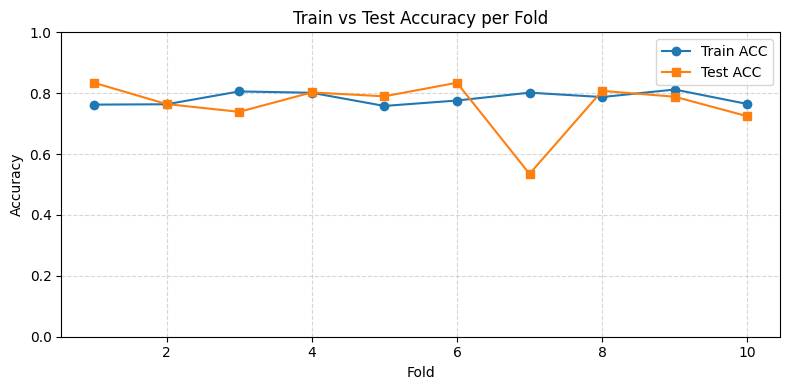

In [7]:
# --- 使用被選滿10次的 features 在原始資料做 10-fold CV（KNN→SMOTE→DT） ---
cv2 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_metrics = []
train_accs = []
test_accs = []
for fid, (tr_idx, va_idx) in enumerate(cv2.split(X[top], y), 1):
    X_tr_raw, X_va_raw = X.iloc[tr_idx][top], X.iloc[va_idx][top]
    y_tr, y_va       = y.iloc[tr_idx], y.iloc[va_idx]

    # 前處理：KNN（fit on train → transform valid）
    knn_imp2 = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imp = pd.DataFrame(knn_imp2.fit_transform(X_tr_raw), columns=top, index=X_tr_raw.index)
    X_va_imp = pd.DataFrame(knn_imp2.transform(X_va_raw),     columns=top, index=X_va_raw.index)

    # SMOTE：只對訓練集
    smote2 = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)
    X_tr_res, y_tr_res = smote2.fit_resample(X_tr_imp, y_tr)

    # 決策樹訓練與驗證
    clf2 = DecisionTreeClassifier(**dt_)
    clf2.fit(X_tr_res, y_tr_res)

    y_tr_pred = clf2.predict(X_tr_res)
    y_va_pred = clf2.predict(X_va_imp)

    fold_res = compute_metrics(y_va, y_va_pred)
    fold_metrics.append(fold_res)
    train_accs.append(accuracy_score(y_tr_res, y_tr_pred))
    test_accs.append(accuracy_score(y_va, y_va_pred))
    print(f"[CV-ON-ORIG Fold {fid:02d}] acc={fold_res['acc']:.4f} "
            f"FAR={fold_res['FAR']:.4f} sens={fold_res['sensitivity']:.4f} "
            f"spec={fold_res['specificity']:.4f} GM={fold_res['GM']:.4f}")

def _m(key): 
    vals = [m[key] for m in fold_metrics if not np.isnan(m[key])]
    return np.mean(vals) if len(vals)>0 else np.nan
print(f"[CV-ON-ORIG MEAN] acc={_m('acc'):.4f} FAR={_m('FAR'):.4f} "
        f"sens={_m('sensitivity'):.4f} spec={_m('specificity'):.4f} GM={_m('GM'):.4f}")

plt.figure(figsize=(8,4))
plt.plot(np.arange(1, len(train_accs)+1), train_accs, marker='o', label='Train ACC')
plt.plot(np.arange(1, len(train_accs)+1), test_accs,  marker='s', label='Test ACC')
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy per Fold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()



#### 有標準化, SMOTE

In [16]:
secom = pd.read_csv(data_path, sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
knn_imp = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)

rf_ = dict(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
dt_ = dict(random_state=42, class_weight='balanced', max_depth=6)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def candidate_k_list(p, m=12):
    m = min(m, p)
    ks = np.unique(np.linspace(min(10, p), p, num=m, dtype=int))
    ks = ks[ks > 0]
    return ks

best_k_per_fold = []
features_per_fold = []
feature_pick_counter = Counter()

for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    
    rf = RandomForestClassifier(**rf_)
    rf.fit(X_tr, y_tr)
    importances = pd.Series(rf.feature_importances_, index=X_tr.columns)
    order = importances.sort_values(ascending=False).index.tolist()

    # 針對不同前 k 個特徵：KNN 補值（只用訓練 fit）、決策樹在 valid 算 acc，取最佳 k
    ks = candidate_k_list(p=len(order), m=12)
    best_acc, best_k, best_feats = -1.0, None, None

    for k in ks:
        sel = order[:k]
        
        X_tr_std = pd.DataFrame(scaler.fit_transform(X_tr[sel]), index=X_tr.index, columns=sel)
        X_va_std = pd.DataFrame(scaler.transform(X_va[sel]), index=X_va.index, columns=sel)

        X_tr_sel_imp = pd.DataFrame(knn_imp.fit_transform(X_tr_std), columns=X_tr_std.columns, index=X_tr_std.index)
        X_va_sel_imp = pd.DataFrame(knn_imp.transform(X_va_std), columns=X_va_std.columns, index=X_va_std.index)

        X_tr_res, y_tr_res = smote.fit_resample(X_tr_sel_imp, y_tr)

        clf = DecisionTreeClassifier(**dt_)
        clf.fit(X_tr_res, y_tr_res)
        va_pred = clf.predict(X_va_sel_imp)
        acc = accuracy_score(y_va, va_pred)

        if acc > best_acc:
            best_acc, best_k, best_feats = acc, k, sel

    best_k_per_fold.append((fold_id, best_k, best_acc))
    features_per_fold.append((fold_id, best_feats))
    feature_pick_counter.update(best_feats)

# ---- 輸出 ----
print("每折最佳 k 與驗證集 accuracy：")
for fid, bk, ba in best_k_per_fold:
    print(f"[Fold {fid:02d}] best_k={bk:<4d}  valid_acc={ba:.4f}")

feat_counts_df = pd.DataFrame(feature_pick_counter.most_common(), columns=['feature', 'selected_count'])

top = feat_counts_df[feat_counts_df['selected_count']==10]['feature'].tolist()

Xtr_std = pd.DataFrame(scaler.fit_transform(X_train[top]), index=X_train.index, columns=top)
Xte_std = pd.DataFrame(scaler.transform(X_test[top]), index=X_test.index, columns=top)

Xtr_imp = pd.DataFrame(knn_imp.fit_transform(Xtr_std), columns=top, index=Xtr_std.index)
Xte_imp = pd.DataFrame(knn_imp.transform(Xte_std), columns=top, index=Xte_std.index)

Xtr_res, ytr_res = smote.fit_resample(Xtr_imp, y_train)

clf = DecisionTreeClassifier(**dt_)
clf.fit(Xtr_res, ytr_res)
yhat = clf.predict(Xte_imp)

res = compute_metrics(y_test, yhat)
print(f"[TEST] acc={res['acc']:.4f} FAR={res['FAR']:.4f} sens={res['sensitivity']:.4f} spec={res['specificity']:.4f} GM={res['GM']:.4f}")
print(res['cm'])

每折最佳 k 與驗證集 accuracy：
[Fold 01] best_k=407   valid_acc=0.8810
[Fold 02] best_k=288   valid_acc=0.8016
[Fold 03] best_k=407   valid_acc=0.8175
[Fold 04] best_k=407   valid_acc=0.7680
[Fold 05] best_k=327   valid_acc=0.8160
[Fold 06] best_k=129   valid_acc=0.8800
[Fold 07] best_k=407   valid_acc=0.8240
[Fold 08] best_k=288   valid_acc=0.9040
[Fold 09] best_k=288   valid_acc=0.8560
[Fold 10] best_k=248   valid_acc=0.8080
[TEST] acc=0.7866 FAR=0.1980 sens=0.5714 spec=0.8020 GM=0.6770
[[235  58]
 [  9  12]]


---
---

#### 沒有做SMOTE

In [13]:
secom = pd.read_csv(data_path, sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

knn_imp = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)

rf_ = dict(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1, class_weight='balanced')
dt_ = dict(random_state=42, class_weight='balanced', max_depth=6)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def candidate_k_list(p, m=12):
    m = min(m, p)
    ks = np.unique(np.linspace(min(10, p), p, num=m, dtype=int))
    ks = ks[ks > 0]
    return ks

best_k_per_fold = []
features_per_fold = []
feature_pick_counter = Counter()

for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    
    rf = RandomForestClassifier(**rf_)
    rf.fit(X_tr, y_tr)

    importances = pd.Series(rf.feature_importances_, index=X_tr.columns)
    order = importances.sort_values(ascending=False).index.tolist()

    # 針對不同前 k 個特徵：KNN 補值（只用訓練 fit）、決策樹在 valid 算 acc，取最佳 k
    ks = candidate_k_list(p=len(order), m=12)
    best_acc, best_k, best_feats = -1.0, None, None

    for k in ks:
        sel = order[:k]

        X_tr_sel_imp = pd.DataFrame(knn_imp.fit_transform(X_tr[sel]), columns=sel, index=X_tr.index)
        X_va_sel_imp = pd.DataFrame(knn_imp.transform(X_va[sel]), columns=sel, index=X_va.index)

        clf = DecisionTreeClassifier(**dt_)
        clf.fit(X_tr_sel_imp, y_tr)
        va_pred = clf.predict(X_va_sel_imp)
        acc = accuracy_score(y_va, va_pred)

        if acc > best_acc:
            best_acc, best_k, best_feats = acc, k, sel

    best_k_per_fold.append((fold_id, best_k, best_acc))
    features_per_fold.append((fold_id, best_feats))
    feature_pick_counter.update(best_feats)

# ---- 輸出 ----
print("每折最佳 k 與驗證集 accuracy：")
for fid, bk, ba in best_k_per_fold:
    print(f"[Fold {fid:02d}] best_k={bk:<4d}  valid_acc={ba:.4f}")

feat_counts_df = pd.DataFrame(feature_pick_counter.most_common(), columns=['feature', 'selected_count'])

top = feat_counts_df[feat_counts_df['selected_count']==10]['feature'].tolist()

Xtr_imp = pd.DataFrame(knn_imp.fit_transform(X_train[top]), columns=top, index=X_train.index)
Xte_imp = pd.DataFrame(knn_imp.transform(X_test[top]), columns=top, index=X_test.index)

clf = DecisionTreeClassifier(**dt_)
clf.fit(Xtr_imp, y_train)
yhat = clf.predict(Xte_imp)

res = compute_metrics(y_test, yhat)
print(f"[TEST] acc={res['acc']:.4f} FAR={res['FAR']:.4f} sens={res['sensitivity']:.4f} spec={res['specificity']:.4f} GM={res['GM']:.4f}")
print(res['cm'])

每折最佳 k 與驗證集 accuracy：
[Fold 01] best_k=89    valid_acc=0.7857
[Fold 02] best_k=129   valid_acc=0.8095
[Fold 03] best_k=49    valid_acc=0.7619
[Fold 04] best_k=10    valid_acc=0.8480
[Fold 05] best_k=10    valid_acc=0.8240
[Fold 06] best_k=10    valid_acc=0.8400
[Fold 07] best_k=49    valid_acc=0.8400
[Fold 08] best_k=49    valid_acc=0.8480
[Fold 09] best_k=129   valid_acc=0.8080
[Fold 10] best_k=168   valid_acc=0.8400
[TEST] acc=0.7166 FAR=0.2491 sens=0.2381 spec=0.7509 GM=0.4228
[[220  73]
 [ 16   5]]


[CV-ON-ORIG Fold 01] acc=0.8344 FAR=0.1429 sens=0.5000 spec=0.8571 GM=0.6547
[CV-ON-ORIG Fold 02] acc=0.6879 FAR=0.2857 sens=0.3000 spec=0.7143 GM=0.4629
[CV-ON-ORIG Fold 03] acc=0.7134 FAR=0.2721 sens=0.5000 spec=0.7279 GM=0.6033
[CV-ON-ORIG Fold 04] acc=0.7325 FAR=0.2466 sens=0.4545 spec=0.7534 GM=0.5852
[CV-ON-ORIG Fold 05] acc=0.7516 FAR=0.2192 sens=0.3636 spec=0.7808 GM=0.5329
[CV-ON-ORIG Fold 06] acc=0.7389 FAR=0.2466 sens=0.5455 spec=0.7534 GM=0.6411
[CV-ON-ORIG Fold 07] acc=0.8089 FAR=0.1438 sens=0.1818 spec=0.8562 GM=0.3945
[CV-ON-ORIG Fold 08] acc=0.8013 FAR=0.1644 sens=0.3000 spec=0.8356 GM=0.5007
[CV-ON-ORIG Fold 09] acc=0.7949 FAR=0.1712 sens=0.3000 spec=0.8288 GM=0.4986
[CV-ON-ORIG Fold 10] acc=0.8269 FAR=0.1438 sens=0.4000 spec=0.8562 GM=0.5852
[CV-ON-ORIG MEAN] acc=0.7691 FAR=0.2036 sens=0.3845 spec=0.7964 GM=0.5459


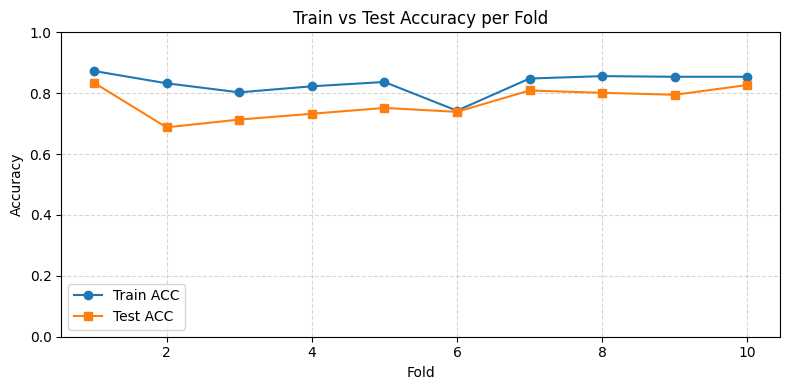

In [9]:
# --- 使用被選滿10次的 features 在原始資料做 10-fold CV（KNN→SMOTE→DT） ---
cv2 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_metrics = []
train_accs = []
test_accs = []
for fid, (tr_idx, va_idx) in enumerate(cv2.split(X[top], y), 1):
    X_tr_raw, X_va_raw = X.iloc[tr_idx][top], X.iloc[va_idx][top]
    y_tr, y_va       = y.iloc[tr_idx], y.iloc[va_idx]

    # 前處理：KNN（fit on train → transform valid）
    knn_imp2 = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imp = pd.DataFrame(knn_imp2.fit_transform(X_tr_raw), columns=top, index=X_tr_raw.index)
    X_va_imp = pd.DataFrame(knn_imp2.transform(X_va_raw),     columns=top, index=X_va_raw.index)

    # 決策樹訓練與驗證
    clf2 = DecisionTreeClassifier(**dt_)
    clf2.fit(X_tr_imp, y_tr)

    y_tr_pred = clf2.predict(X_tr_imp)
    y_va_pred = clf2.predict(X_va_imp)

    fold_res = compute_metrics(y_va, y_va_pred)
    fold_metrics.append(fold_res)
    train_accs.append(accuracy_score(y_tr, y_tr_pred))
    test_accs.append(accuracy_score(y_va, y_va_pred))
    print(f"[CV-ON-ORIG Fold {fid:02d}] acc={fold_res['acc']:.4f} "
            f"FAR={fold_res['FAR']:.4f} sens={fold_res['sensitivity']:.4f} "
            f"spec={fold_res['specificity']:.4f} GM={fold_res['GM']:.4f}")

def _m(key): 
    vals = [m[key] for m in fold_metrics if not np.isnan(m[key])]
    return np.mean(vals) if len(vals)>0 else np.nan
print(f"[CV-ON-ORIG MEAN] acc={_m('acc'):.4f} FAR={_m('FAR'):.4f} "
        f"sens={_m('sensitivity'):.4f} spec={_m('specificity'):.4f} GM={_m('GM'):.4f}")

plt.figure(figsize=(8,4))
plt.plot(np.arange(1, len(train_accs)+1), train_accs, marker='o', label='Train ACC')
plt.plot(np.arange(1, len(train_accs)+1), test_accs,  marker='s', label='Test ACC')
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy per Fold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()



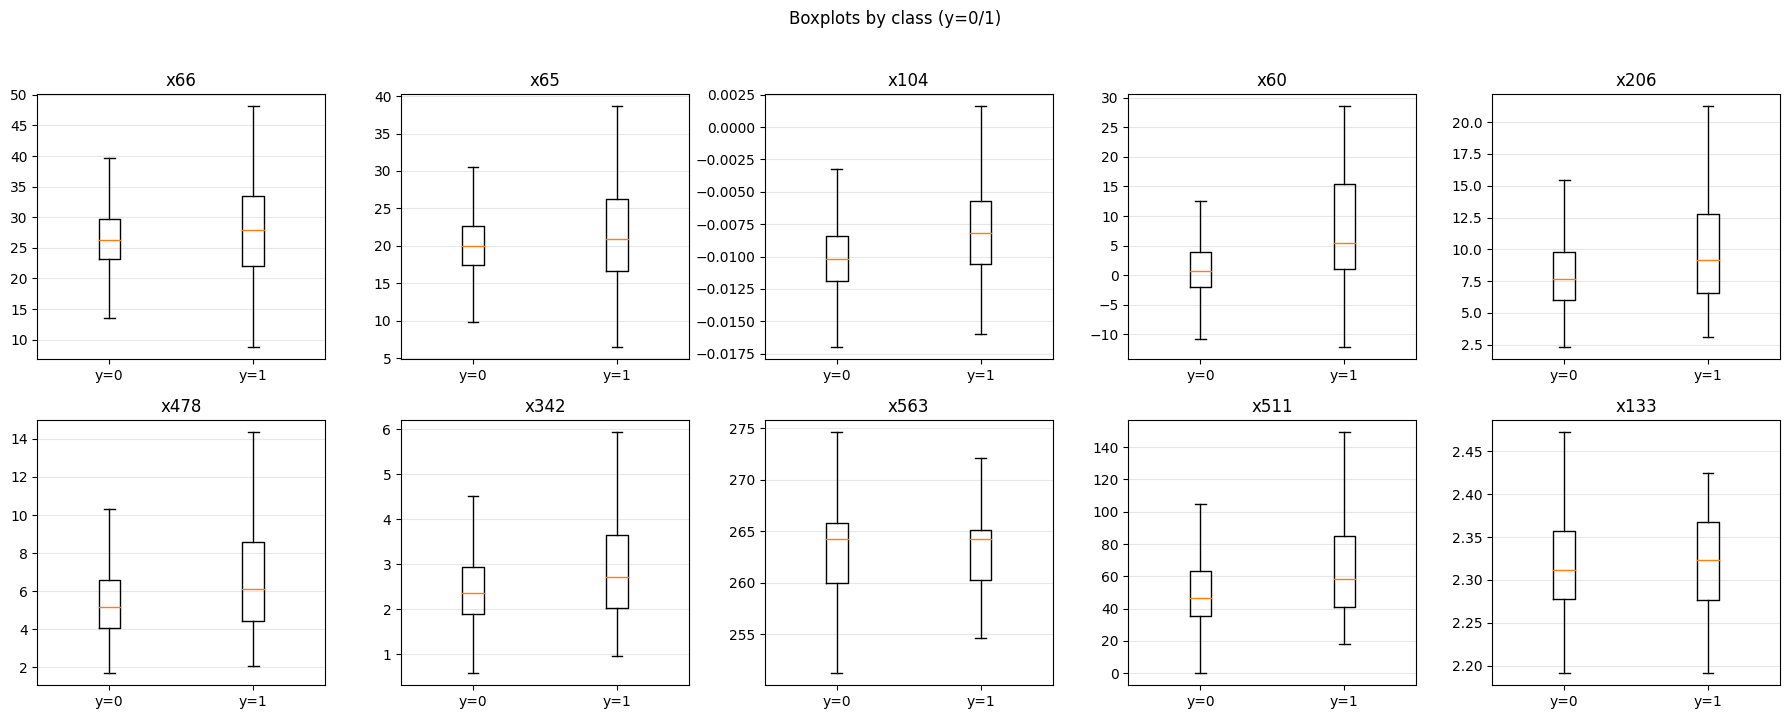

In [11]:
top_feats = ['x66','x65','x104','x60','x206','x478','x342','x563','x511','x133']
df_box = pd.concat([X[top_feats].copy(), y.rename('y')], axis=1)

# 長表
long_df = df_box.melt(id_vars='y', value_vars=top_feats, var_name='feature', value_name='value')

# 畫圖（每個特徵一張，分 0/1 兩個 box）
n = len(top_feats)
rows = 2
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(18, 7), sharey=False)
axes = axes.ravel()

for i, f in enumerate(top_feats):
    ax = axes[i]
    sub = long_df[long_df['feature']==f]
    data0 = sub.loc[sub['y']==0, 'value'].dropna()
    data1 = sub.loc[sub['y']==1, 'value'].dropna()
    ax.boxplot([data0, data1], labels=['y=0','y=1'], showfliers=False)
    ax.set_title(f)
    ax.grid(True, axis='y', alpha=0.3)

# 若不足 10 格，隱藏多餘子圖
for j in range(i+1, rows*cols):
    axes[j].axis('off')

fig.suptitle('Boxplots by class (y=0/1)', y=1.02)
plt.tight_layout()
plt.show()

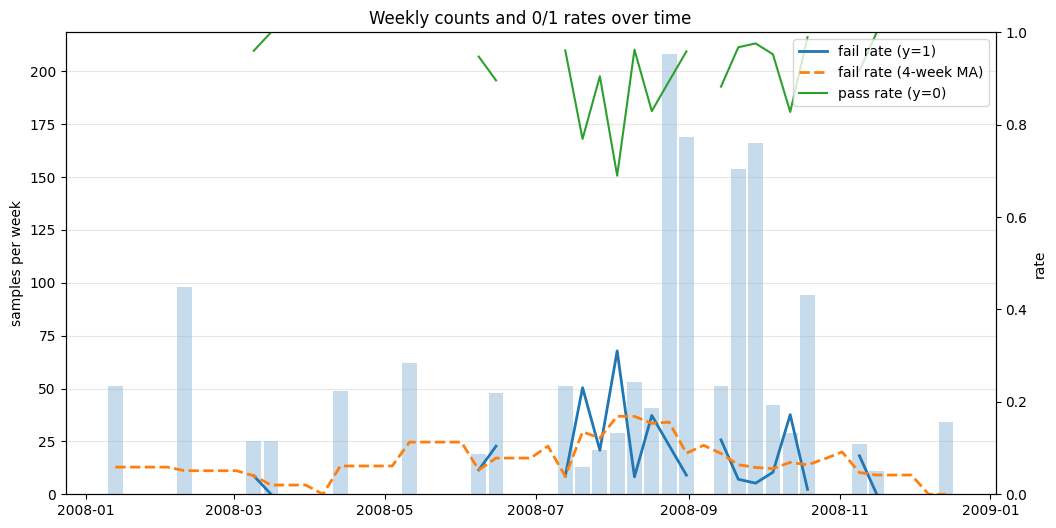

In [12]:
# 建立時間序列（確保時間排序＆索引）
y01 = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)
time_dt = pd.to_datetime(secom['Time'])
ts = pd.DataFrame({'Time': time_dt, 'y': y01}).sort_values('Time').set_index('Time')

# 以「週」彙整：樣本數與失敗率（= 平均 y）
w = ts['y'].resample('W')
cnt, rate = w.size(), w.mean()

# 可選：平滑（移動平均）
rate_smooth = rate.rolling(window=4, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))
# 左軸：每週樣本數
ax1.bar(cnt.index, cnt.values, width=6, alpha=0.25)
ax1.set_ylabel('samples per week')
ax1.grid(True, axis='y', alpha=0.3)

# 右軸：失敗率(= y=1)，以及通過率(=1-rate)
ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, linewidth=2, label='fail rate (y=1)')
ax2.plot(rate_smooth.index, rate_smooth.values, linewidth=2, linestyle='--', label='fail rate (4-week MA)')
ax2.plot(rate.index, (1-rate).values, linewidth=1.5, label='pass rate (y=0)')
ax2.set_ylabel('rate')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')

plt.title('Weekly counts and 0/1 rates over time')
plt.show()

#### 有標準化 TEST沒有SMOTE

In [17]:
secom = pd.read_csv(data_path, sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
knn_imp = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)

rf_ = dict(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
dt_ = dict(random_state=42, class_weight='balanced', max_depth=6)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def candidate_k_list(p, m=12):
    m = min(m, p)
    ks = np.unique(np.linspace(min(10, p), p, num=m, dtype=int))
    ks = ks[ks > 0]
    return ks

best_k_per_fold = []
features_per_fold = []
feature_pick_counter = Counter()

for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    
    rf = RandomForestClassifier(**rf_)
    rf.fit(X_tr, y_tr)
    importances = pd.Series(rf.feature_importances_, index=X_tr.columns)
    order = importances.sort_values(ascending=False).index.tolist()

    # 針對不同前 k 個特徵：KNN 補值（只用訓練 fit）、決策樹在 valid 算 acc，取最佳 k
    ks = candidate_k_list(p=len(order), m=12)
    best_acc, best_k, best_feats = -1.0, None, None

    for k in ks:
        sel = order[:k]
        
        X_tr_std = pd.DataFrame(scaler.fit_transform(X_tr[sel]), index=X_tr.index, columns=sel)
        X_va_std = pd.DataFrame(scaler.transform(X_va[sel]), index=X_va.index, columns=sel)

        X_tr_sel_imp = pd.DataFrame(knn_imp.fit_transform(X_tr_std), columns=X_tr_std.columns, index=X_tr_std.index)
        X_va_sel_imp = pd.DataFrame(knn_imp.transform(X_va_std), columns=X_va_std.columns, index=X_va_std.index)

        X_tr_res, y_tr_res = smote.fit_resample(X_tr_sel_imp, y_tr)

        clf = DecisionTreeClassifier(**dt_)
        clf.fit(X_tr_res, y_tr_res)
        va_pred = clf.predict(X_va_sel_imp)
        acc = accuracy_score(y_va, va_pred)

        if acc > best_acc:
            best_acc, best_k, best_feats = acc, k, sel

    best_k_per_fold.append((fold_id, best_k, best_acc))
    features_per_fold.append((fold_id, best_feats))
    feature_pick_counter.update(best_feats)

# ---- 輸出 ----
print("每折最佳 k 與驗證集 accuracy：")
for fid, bk, ba in best_k_per_fold:
    print(f"[Fold {fid:02d}] best_k={bk:<4d}  valid_acc={ba:.4f}")

feat_counts_df = pd.DataFrame(feature_pick_counter.most_common(), columns=['feature', 'selected_count'])

top = feat_counts_df[feat_counts_df['selected_count']==10]['feature'].tolist()

Xtr_std = pd.DataFrame(scaler.fit_transform(X_train[top]), index=X_train.index, columns=top)
Xte_std = pd.DataFrame(scaler.transform(X_test[top]), index=X_test.index, columns=top)

Xtr_imp = pd.DataFrame(knn_imp.fit_transform(Xtr_std), columns=top, index=Xtr_std.index)
Xte_imp = pd.DataFrame(knn_imp.transform(Xte_std), columns=top, index=Xte_std.index)

clf = DecisionTreeClassifier(**dt_)
clf.fit(Xtr_imp, y_train)
yhat = clf.predict(Xte_imp)

res = compute_metrics(y_test, yhat)
print(f"[TEST] acc={res['acc']:.4f} FAR={res['FAR']:.4f} sens={res['sensitivity']:.4f} spec={res['specificity']:.4f} GM={res['GM']:.4f}")
print(res['cm'])

每折最佳 k 與驗證集 accuracy：
[Fold 01] best_k=407   valid_acc=0.8810
[Fold 02] best_k=288   valid_acc=0.8016
[Fold 03] best_k=407   valid_acc=0.8175
[Fold 04] best_k=407   valid_acc=0.7680
[Fold 05] best_k=327   valid_acc=0.8160
[Fold 06] best_k=129   valid_acc=0.8800
[Fold 07] best_k=407   valid_acc=0.8240
[Fold 08] best_k=288   valid_acc=0.9040
[Fold 09] best_k=288   valid_acc=0.8560
[Fold 10] best_k=248   valid_acc=0.8080
[TEST] acc=0.7962 FAR=0.1775 sens=0.4286 spec=0.8225 GM=0.5937
[[241  52]
 [ 12   9]]


In [18]:
feat_counts_df[feat_counts_df['selected_count'] ==10]


,feature,selected_count
0,x66,10
1,x65,10
2,x104,10
3,x60,10
4,x206,10
...,...,...
109,x79,10
110,x295,10
111,x577,10
112,x578,10


---
---

In [17]:
secom = pd.read_csv(data_path, sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf_ = dict(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
knn_imp = KNNImputer(n_neighbors=10, weights='distance')
svc_ = dict(kernel='rbf', C=1.0, gamma='auto', class_weight='balanced', random_state=42)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def candidate_k_list(p, m=12):
    m = min(m, p)
    ks = np.unique(np.linspace(min(10, p), p, num=m, dtype=int))
    ks = ks[ks > 0]
    return ks

best_k_per_fold = []
features_per_fold = []
feature_pick_counter = Counter()

for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    rf = RandomForestClassifier(**rf_)
    rf.fit(X_tr, y_tr)

    importances = pd.Series(rf.feature_importances_, index=X_tr.columns)
    order = importances.sort_values(ascending=False).index.tolist()

    # 針對不同前 k 個特徵：KNN 補值（只用訓練 fit）、決策樹在 valid 算 acc，取最佳 k
    ks = candidate_k_list(p=len(order), m=12)
    best_acc, best_k, best_feats = -1.0, None, None

    for k in ks:
        sel = order[:k]

        X_tr_sel_imp = pd.DataFrame(knn_imp.fit_transform(X_tr[sel]), columns=sel, index=X_tr.index)
        X_va_sel_imp = pd.DataFrame(knn_imp.transform(X_va[sel]), columns=sel, index=X_va.index)

        scaler = StandardScaler()
        X_tr_sel_std = pd.DataFrame(scaler.fit_transform(X_tr_sel_imp), columns=sel, index=X_tr.index)
        X_va_sel_std = pd.DataFrame(scaler.transform(X_va_sel_imp),     columns=sel, index=X_va.index)

        svc = SVC(**svc_)
        svc.fit(X_tr_sel_std, y_tr)
        va_pred = svc.predict(X_va_sel_std)
        acc = accuracy_score(y_va, va_pred)

        if acc > best_acc:
            best_acc, best_k, best_feats = acc, k, sel

    best_k_per_fold.append((fold_id, best_k, best_acc))
    features_per_fold.append((fold_id, best_feats))
    feature_pick_counter.update(best_feats)

# ---- 輸出 ----
print("SVC 每折最佳 k 與驗證集 accuracy：")
for fid, bk, ba in best_k_per_fold:
    print(f"[Fold {fid:02d}] best_k={bk:<4d}  valid_acc={ba:.4f}")

feat_counts_df = pd.DataFrame(feature_pick_counter.most_common(), columns=['feature', 'selected_count'])

top = feat_counts_df[feat_counts_df['selected_count']==10]['feature'].tolist()

Xtr_imp = pd.DataFrame(knn_imp.fit_transform(X_train[top]), columns=top, index=X_train.index)
Xte_imp = pd.DataFrame(knn_imp.transform(X_test[top]), columns=top, index=X_test.index)

scaler = StandardScaler()
Xtr_std = pd.DataFrame(scaler.fit_transform(Xtr_imp), columns=top, index=X_train.index)
Xte_std = pd.DataFrame(scaler.transform(Xte_imp),     columns=top, index=X_test.index)

svc = SVC(**svc_)  # 與前述相同：gini, max_depth=6, class_weight='balanced', random_state=42
svc.fit(Xtr_std, y_train)
yhat = svc.predict(Xte_std)

res = compute_metrics(y_test, yhat)
print(f"[TEST] acc={res['acc']:.4f} FAR={res['FAR']:.4f} sens={res['sensitivity']:.4f} spec={res['specificity']:.4f} GM={res['GM']:.4f}")
print(res['cm'])

SVC 每折最佳 k 與驗證集 accuracy：
[Fold 01] best_k=447   valid_acc=0.9206
[Fold 02] best_k=129   valid_acc=0.9524
[Fold 03] best_k=248   valid_acc=0.8651
[Fold 04] best_k=168   valid_acc=0.9360
[Fold 05] best_k=208   valid_acc=0.9360
[Fold 06] best_k=407   valid_acc=0.9440
[Fold 07] best_k=367   valid_acc=0.9280
[Fold 08] best_k=288   valid_acc=0.9360
[Fold 09] best_k=447   valid_acc=0.9440
[Fold 10] best_k=327   valid_acc=0.9120
[TEST] acc=0.8917 FAR=0.0580 sens=0.1905 spec=0.9420 GM=0.4236
[[276  17]
 [ 17   4]]


[CV-ON-ORIG Fold 01] acc=0.8854 FAR=0.0816 sens=0.4000 spec=0.9184 GM=0.6061
[CV-ON-ORIG Fold 02] acc=0.8854 FAR=0.0612 sens=0.1000 spec=0.9388 GM=0.3064
[CV-ON-ORIG Fold 03] acc=0.8599 FAR=0.0816 sens=0.0000 spec=0.9184 GM=0.0000
[CV-ON-ORIG Fold 04] acc=0.9045 FAR=0.0342 sens=0.0909 spec=0.9658 GM=0.2963
[CV-ON-ORIG Fold 05] acc=0.8981 FAR=0.0548 sens=0.2727 spec=0.9452 GM=0.5077
[CV-ON-ORIG Fold 06] acc=0.8917 FAR=0.0479 sens=0.0909 spec=0.9521 GM=0.2942
[CV-ON-ORIG Fold 07] acc=0.9045 FAR=0.0342 sens=0.0909 spec=0.9658 GM=0.2963
[CV-ON-ORIG Fold 08] acc=0.8910 FAR=0.0479 sens=0.0000 spec=0.9521 GM=0.0000
[CV-ON-ORIG Fold 09] acc=0.8974 FAR=0.0548 sens=0.2000 spec=0.9452 GM=0.4348
[CV-ON-ORIG Fold 10] acc=0.9167 FAR=0.0342 sens=0.2000 spec=0.9658 GM=0.4395
[CV-ON-ORIG MEAN] acc=0.8934 FAR=0.0533 sens=0.1445 spec=0.9467 GM=0.3181


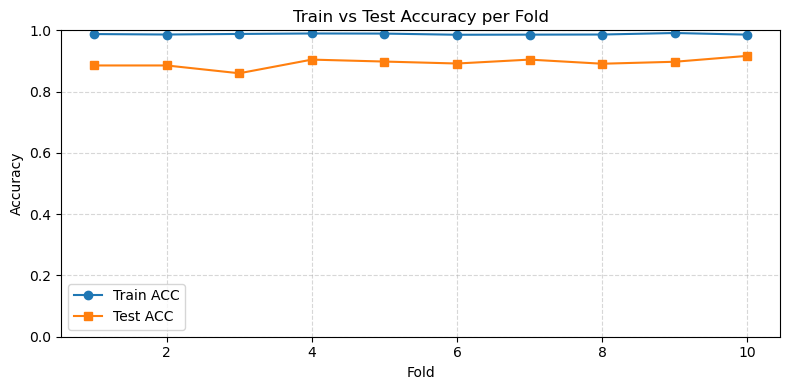

In [23]:
# --- 使用被選滿10次的 features 在原始資料做 10-fold CV（KNN→SMOTE→DT） ---
cv2 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_metrics = []
train_accs = []
test_accs = []
for fid, (tr_idx, va_idx) in enumerate(cv2.split(X[top], y), 1):
    X_tr_raw, X_va_raw = X.iloc[tr_idx][top], X.iloc[va_idx][top]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    # 前處理：KNN（fit on train → transform valid）
    knn_imp2 = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imp = pd.DataFrame(knn_imp2.fit_transform(X_tr_raw), columns=top, index=X_tr_raw.index)
    X_va_imp = pd.DataFrame(knn_imp2.transform(X_va_raw), columns=top, index=X_va_raw.index)

    scaler = StandardScaler()
    X_tr_std = pd.DataFrame(scaler.fit_transform(X_tr_imp), columns=top, index=X_tr_imp.index)
    X_va_std = pd.DataFrame(scaler.transform(X_va_imp),     columns=top, index=X_va_imp.index)

    # SMOTE：只對訓練集
    smote2 = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)
    X_tr_res, y_tr_res = smote2.fit_resample(X_tr_std, y_tr)

    # 訓練與驗證
    svc2 = SVC(**svc_)
    svc2.fit(X_tr_res, y_tr_res)

    y_tr_pred = svc2.predict(X_tr_res)
    y_va_pred = svc2.predict(X_va_std)

    fold_res = compute_metrics(y_va, y_va_pred)
    fold_metrics.append(fold_res)
    train_accs.append(accuracy_score(y_tr_res, y_tr_pred))
    test_accs.append(accuracy_score(y_va, y_va_pred))
    print(f"[CV-ON-ORIG Fold {fid:02d}] acc={fold_res['acc']:.4f} "
            f"FAR={fold_res['FAR']:.4f} sens={fold_res['sensitivity']:.4f} "
            f"spec={fold_res['specificity']:.4f} GM={fold_res['GM']:.4f}")

def _m(key): 
    vals = [m[key] for m in fold_metrics if not np.isnan(m[key])]
    return np.mean(vals) if len(vals)>0 else np.nan
print(f"[CV-ON-ORIG MEAN] acc={_m('acc'):.4f} FAR={_m('FAR'):.4f} "
        f"sens={_m('sensitivity'):.4f} spec={_m('specificity'):.4f} GM={_m('GM'):.4f}")

plt.figure(figsize=(8,4))
plt.plot(np.arange(1, len(train_accs)+1), train_accs, marker='o', label='Train ACC')
plt.plot(np.arange(1, len(train_accs)+1), test_accs,  marker='s', label='Test ACC')
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy per Fold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


In [19]:
feat_counts_df['selected_count'].value_counts()

selected_count
10    92
5     59
9     56
6     55
4     49
8     47
7     42
3     27
2     20
Name: count, dtype: int64

In [6]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf_ = dict(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
knn_imp = KNNImputer(n_neighbors=10, weights='distance')
xgb_ = dict(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, tree_method='hist', eval_metric='logloss')

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def candidate_k_list(p, m=12):
    m = min(m, p)
    ks = np.unique(np.linspace(min(10, p), p, num=m, dtype=int))
    ks = ks[ks > 0]
    return ks

best_k_per_fold = []
features_per_fold = []
feature_pick_counter = Counter()

for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    rf = RandomForestClassifier(**rf_)
    rf.fit(X_tr, y_tr)

    importances = pd.Series(rf.feature_importances_, index=X_tr.columns)
    order = importances.sort_values(ascending=False).index.tolist()

    # 針對不同前 k 個特徵：KNN 補值（只用訓練 fit）、決策樹在 valid 算 acc，取最佳 k
    ks = candidate_k_list(p=len(order), m=12)
    best_acc, best_k, best_feats = -1.0, None, None

    for k in ks:
        sel = order[:k]

        X_tr_sel_imp = pd.DataFrame(knn_imp.fit_transform(X_tr[sel]), columns=sel, index=X_tr.index)
        X_va_sel_imp = pd.DataFrame(knn_imp.transform(X_va[sel]), columns=sel, index=X_va.index)

        xgb = XGBClassifier(**xgb_)
        xgb.fit(X_tr_sel_imp, y_tr)
        va_pred = xgb.predict(X_va_sel_imp)
        acc = accuracy_score(y_va, va_pred)

        if acc > best_acc:
            best_acc, best_k, best_feats = acc, k, sel

    best_k_per_fold.append((fold_id, best_k, best_acc))
    features_per_fold.append((fold_id, best_feats))
    feature_pick_counter.update(best_feats)

# ---- 輸出 ----
print("每折最佳 k 與驗證集 accuracy：")
for fid, bk, ba in best_k_per_fold:
    print(f"[Fold {fid:02d}] best_k={bk:<4d}  valid_acc={ba:.4f}")

feat_counts_df = pd.DataFrame(feature_pick_counter.most_common(), columns=['feature', 'selected_count'])

top = feat_counts_df[feat_counts_df['selected_count']==10]['feature'].tolist()

Xtr_imp = pd.DataFrame(knn_imp.fit_transform(X_train[top]), columns=top, index=X_train.index)
Xte_imp = pd.DataFrame(knn_imp.transform(X_test[top]), columns=top, index=X_test.index)

xgb = XGBClassifier(**xgb_)  # 與前述相同：gini, max_depth=6, class_weight='balanced', random_state=42
xgb.fit(Xtr_imp, y_train)
yhat = xgb.predict(Xte_imp)

res = compute_metrics(y_test, yhat)
print(f"[TEST] acc={res['acc']:.4f} FAR={res['FAR']:.4f} sens={res['sensitivity']:.4f} spec={res['specificity']:.4f} GM={res['GM']:.4f}")
print(res['cm'])

每折最佳 k 與驗證集 accuracy：
[Fold 01] best_k=10    valid_acc=0.9286
[Fold 02] best_k=129   valid_acc=0.9444
[Fold 03] best_k=89    valid_acc=0.9286
[Fold 04] best_k=10    valid_acc=0.9440
[Fold 05] best_k=10    valid_acc=0.9360
[Fold 06] best_k=49    valid_acc=0.9520
[Fold 07] best_k=10    valid_acc=0.9360
[Fold 08] best_k=10    valid_acc=0.9360
[Fold 09] best_k=10    valid_acc=0.9360
[Fold 10] best_k=89    valid_acc=0.9360
[TEST] acc=0.9331 FAR=0.0034 sens=0.0476 spec=0.9966 GM=0.2178
[[292   1]
 [ 20   1]]


---
---

In [44]:
secom = pd.read_csv(data_path, sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def zscore_by_ref(train_df: pd.DataFrame, valid_df: pd.DataFrame):
    mean = train_df.mean(skipna=True)
    std = train_df.std(skipna=True, ddof=0).replace(0, 1)

    Xtr_std = (train_df - mean) / std
    Xva_std = (valid_df - mean) / std
    return Xtr_std, Xva_std, mean, std

# === 四個模型（先用穩健、適中的基本參數；你之後可再調）===
def make_models():
    return {
        "XGB": XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss',tree_method='hist'),
        "RF": RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, class_weight='balanced', random_state=42, n_jobs=-1),
        "DT": DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
        "SVC": SVC(kernel='rbf', C=1.0, gamma='auto', class_weight='balanced', random_state=42),
    }

rf = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
order = importances.sort_values(ascending=False).index.tolist()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

knn_imp = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)

fold_datasets = []
processed_folds = []
for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    
    fold_info = {"fold_id":fold_id,
                 "X_tr":X_tr,"y_tr": y_tr,
                 "X_va":X_va,"y_va": y_va, "feature_order":order}
    fold_datasets.append(fold_info)

for fd in fold_datasets:
    fid  = fd["fold_id"]
    X_tr = fd["X_tr"].copy()
    y_tr = fd["y_tr"].copy()
    X_va = fd["X_va"].copy()
    y_va = fd["y_va"].copy()

    # 1) 先標準化（以訓練折統計量；允許 NaN 存在時先做 z-score）
    X_tr_std, X_va_std, mean_ref, std_ref = zscore_by_ref(X_tr, X_va)
    
    X_tr_imp = pd.DataFrame(knn_imp.fit_transform(X_tr_std), columns=X_tr_std.columns, index=X_tr_std.index)
    X_va_imp = pd.DataFrame(knn_imp.transform(X_va_std), columns=X_va_std.columns, index=X_va_std.index)

    X_tr_bal, y_tr_bal = smote.fit_resample(X_tr_imp, y_tr)
    
    # 驗證折不做 SMOTE
    processed_folds.append({
        "fold_id": fid,
        "X_train_bal":X_tr_bal, "y_train_bal":y_tr_bal, # 訓練用
        "X_valid_imp":X_va_imp, "y_valid":y_va, # 驗證用
        "zscore_mean":mean_ref, "zscore_std":std_ref,
        "knn_imputer":knn_imp,
        "feature_order":order  
    })

# === 你要測試的 top-k 清單（可自行調整）===
K_LIST = list(range(10, 205, 5))

# === 逐折 × 逐模型 × 逐 k 訓練與評估 ===
grid_rows = []

for fd in processed_folds:
    fid = fd["fold_id"]
    Xtr = fd["X_train_bal"]   # 已標準化 + 差補 + SMOTE
    ytr = fd["y_train_bal"]
    Xva = fd["X_valid_imp"]   # 已標準化 + 差補（不做 SMOTE）
    yva = fd["y_valid"]
    order = fd["feature_order"]

    p = Xtr.shape[1]
    Ks = [k for k in K_LIST if k <= p] if any(k <= p for k in K_LIST) else [p]

    models = make_models()

    for model_name, model in models.items():
        for k in Ks:
            feat_k = order[:k]
            Xtr_k = Xtr[feat_k]
            Xva_k = Xva[feat_k]

            model.fit(Xtr_k, ytr)

            ytr_hat = model.predict(Xtr_k)
            yva_hat = model.predict(Xva_k)

            tr_acc = accuracy_score(ytr, ytr_hat)
            va_acc = accuracy_score(yva, yva_hat)
            cm = confusion_matrix(yva, yva_hat, labels=[0, 1])
            TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
            va_sen = TP/(TP+FN) if (TP+FN)>0 else np.nan
            va_spe = TN/(TN+FP) if (TN+FP)>0 else np.nan
            va_FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
            grid_rows.append({
                "fold": fid,
                "model": model_name,
                "k": k,
                "train_acc": tr_acc,
                "valid_acc": va_acc,
                'valid_FAR': va_FAR,
                'valid_sensitivity': va_sen,
                'valid_specificity': va_spe
            })

grid_results = pd.DataFrame(grid_rows).sort_values(["model", "fold", "k"]).reset_index(drop=True)

# === 以 valid_acc 選各折各模型的最佳 k（若同分，取較小的 k）===
# 排序：valid_acc 由大到小，同分時 k 由小到大

best_by_model_fold = (
    grid_results
      .assign(valid_acc_filled=lambda d: d["valid_acc"].fillna(-np.inf))
      .sort_values(["model","fold","valid_acc_filled","k"],
                   ascending=[True, True, False, True])  # 先最高 valid_acc，再較小 k
      .groupby(["model","fold"], as_index=False)
      .first()[["model","fold","k","train_acc","valid_acc","valid_FAR","valid_sensitivity","valid_specificity"]]
)

print("\n=== 每個模型 × 每一折的最佳 top-k（依 valid_acc）===")
print(best_by_model_fold)




=== 每個模型 × 每一折的最佳 top-k（依 valid_acc）===
   model  fold    k  train_acc  valid_acc  valid_FAR  valid_sensitivity  \
0     DT     1   40   0.925748   0.804781   0.153846           0.235294   
1     DT     2   75   0.877671   0.796813   0.170940           0.352941   
2     DT     3   75   0.907585   0.796813   0.175214           0.411765   
3     DT     4   35   0.879808   0.780000   0.192308           0.375000   
4     DT     5   35   0.868056   0.840000   0.111111           0.125000   
5     RF     1  155   0.981303   0.904382   0.047009           0.235294   
6     RF     2  120   0.963141   0.896414   0.076923           0.529412   
7     RF     3  185   0.976496   0.920319   0.042735           0.411765   
8     RF     4  175   0.975962   0.908000   0.051282           0.312500   
9     RF     5  145   0.977030   0.900000   0.068376           0.437500   
10   SVC     1  105   0.989850   0.932271   0.021368           0.294118   
11   SVC     2  190   0.993590   0.904382   0.047009       

In [47]:
# === 先用 5 折結果挑各模型全域最佳 k（依 valid_acc 平均最大，平手取較小 k）===
# 這裡假設你已經有 grid_results（包含 fold, model, k, train_acc, valid_acc）
best_k_by_model = (
    grid_results.groupby(["model", "k"], as_index=False)["valid_acc"].mean()
    .rename(columns={"valid_acc": "cv_mean_valid_acc"})
    .sort_values(["model", "cv_mean_valid_acc", "k"], ascending=[True, False, True])
    .groupby("model", as_index=False)
    .first()[["model", "k", "cv_mean_valid_acc"]]
)
print("\n=== 各模型全域最佳 k（來自 5 折 valid_acc 平均）===")
print(best_k_by_model)

# === 在整個 training set 上重做預處理（標準化→KNN差補→SMOTE），再用最佳 k 重訓 ===
# 注意：測試集只做標準化+差補，不做 SMOTE
# 需要：zscore_by_ref, knn_imp, smote, order, make_models, X_train, X_test, y_train, y_test 已存在

# 1) 標準化（以 training set 統計量）
Xtr_full_std, Xte_std, mean_ref_full, std_ref_full = zscore_by_ref(X_train, X_test)

# 2) KNN 差補（fit on train → transform test）
knn_imp_full = KNNImputer(n_neighbors=10, weights='distance')
Xtr_full_imp = pd.DataFrame(
    knn_imp_full.fit_transform(Xtr_full_std),
    columns=Xtr_full_std.columns, index=Xtr_full_std.index
)
Xte_imp = pd.DataFrame(
    knn_imp_full.transform(Xte_std),
    columns=Xte_std.columns, index=Xte_std.index
)

# 3) 訓練集做 SMOTE；測試集不做
Xtr_bal_full, ytr_bal_full = smote.fit_resample(Xtr_full_imp, y_train)

# 4) 依各模型最佳 k 重新訓練，並在 testing set 得到最終成績
from sklearn.metrics import accuracy_score

models = make_models()
final_rows = []
for _, r in best_k_by_model.iterrows():
    model_name = r["model"]
    k_best = int(r["k"])
    cv_mean = float(r["cv_mean_valid_acc"])

    feat_k = order[:k_best]
    clf = models[model_name]

    # 訓練（訓練資料：標準化+差補+SMOTE）
    clf.fit(Xtr_bal_full[feat_k], ytr_bal_full)

    # 訓練集與測試集預測
    yhat_tr = clf.predict(Xtr_bal_full[feat_k])
    yhat_te = clf.predict(Xte_imp[feat_k])

    tr_acc = accuracy_score(ytr_bal_full, yhat_tr)
    te_acc = accuracy_score(y_test, yhat_te)

    # === 新增：計算測試集 FAR ===
    cm_test = confusion_matrix(y_test, yhat_te, labels=[0, 1])
    TN, FP, FN, TP = cm_test[0,0], cm_test[0,1], cm_test[1,0], cm_test[1,1]
    test_FAR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

    final_rows.append({
        "model": model_name,
        "k_best": k_best,
        "cv_mean_valid_acc": cv_mean,
        "train_acc_on_balanced": tr_acc,
        "test_acc": te_acc,
        "test_FAR": test_FAR
    })
    print(cm_test)
final_results = pd.DataFrame(final_rows).sort_values("model").reset_index(drop=True)

print("\n=== 最終 Testing Set 結果（各模型用 5 折挑出的最佳 k）===")
print(final_results)

# 需要的話也可輸出：
# best_k_by_model.to_csv("best_k_by_model_from_cv.csv", index=False)
# final_results.to_csv("final_test_results.csv", index=False)



=== 各模型全域最佳 k（來自 5 折 valid_acc 平均）===
  model    k  cv_mean_valid_acc
0    DT   75           0.785297
1    RF  185           0.901833
2   SVC  195           0.916204
3   XGB  180           0.928972
[[204  89]
 [ 12   9]]
[[277  16]
 [ 15   6]]
[[284   9]
 [ 19   2]]
[[288   5]
 [ 20   1]]

=== 最終 Testing Set 結果（各模型用 5 折挑出的最佳 k）===
  model  k_best  cv_mean_valid_acc  train_acc_on_balanced  test_acc  test_FAR
0    DT      75           0.785297               0.874359  0.678344  0.303754
1    RF     185           0.901833               0.969231  0.901274  0.054608
2   SVC     195           0.916204               0.993590  0.910828  0.030717
3   XGB     180           0.928972               1.000000  0.920382  0.017065


---
---

In [ ]:
secom = pd.read_csv(data_path, sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

# ========= train/test split =========
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ========= KNN補值 =========
imputer = SimpleImputer(strategy='median')
X_tr_imp = pd.DataFrame(imputer.fit_transform(X_tr_raw), columns=X.columns, index=X_tr_raw.index)
X_te_imp = pd.DataFrame(imputer.transform(X_te_raw), columns=X.columns, index=X_te_raw.index)

# ========= 先平方，再標準化原特徵 =========
X_tr_sq = X_tr_imp ** 2
X_te_sq = X_te_imp ** 2
X_tr_sq.columns = [f"sq_{c}" for c in X.columns]
X_te_sq.columns = X_tr_sq.columns

scaler = StandardScaler()
X_tr_std = pd.DataFrame(scaler.fit_transform(X_tr_imp), columns=X.columns, index=X_tr_imp.index)
X_te_std = pd.DataFrame(scaler.transform(X_te_imp), columns=X.columns, index=X_te_imp.index)

# ========= OLS (訓練集上) 取顯著特徵 =========
X_tr_const = sm.add_constant(X_tr_std, has_constant='add')
ols_model = sm.OLS(y_tr, X_tr_const).fit()
pvals = ols_model.pvalues.drop('const', errors='ignore').sort_values()
sig_feats = pvals[pvals < 0.05].index.tolist()

# ========= 組合「顯著原特徵 + 所有平方特徵」 =========
Xtr_aug = pd.concat([X_tr_std[sig_feats], X_tr_sq], axis=1)
Xte_aug = pd.concat([X_te_std[sig_feats], X_te_sq], axis=1)

# ========= SMOTE（只在訓練集） =========
minority_n = y_tr.value_counts().min()
k_sm = max(1, min(5, minority_n - 1))
smote = SMOTE(k_neighbors=k_sm, random_state=42)
Xb_tr, yb_tr = smote.fit_resample(Xtr_aug, y_tr)

# ========= 評估函數 =========
def eval_and_print(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    far = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    print(f"[{name}] acc={acc:.4f} FAR={far:.4f}")
    print(cm)

# ========= RandomForest =========
rf = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(Xb_tr, yb_tr)
y_pred_rf = rf.predict(Xte_aug)
eval_and_print("RandomForest", y_te, y_pred_rf)

# ========= XGBoost =========
xgb = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss',tree_method='hist')
xgb.fit(Xb_tr, yb_tr)
y_pred_xgb = xgb.predict(Xte_aug)
eval_and_print("XGBoost", y_te, y_pred_xgb)

##### 中位數
[RandomForest] acc=0.9076 FAR=0.0375
| |0|1|
|-|-|-|
|0|282|11|
|1|18 |3|

[XGBoost] acc=0.9236 FAR=0.0102
 | |0|1|
|-|-|-|
|0|290|3|
|1|21 |0|

##### KNN
[RandomForest] acc=0.8981 FAR=0.0478
| |0|1|
|-|-|-|
|0|279|14|
|1|18 |3|

[XGBoost] acc=0.9268 FAR=0.0068
 | |0|1|
|-|-|-|
|0|291|2|
|1|21 |0|